In [29]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if not torch.cuda.is_available():
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device: %s" % device)

Using device: cpu


In [30]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

classes = ("airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck")

In [31]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3072, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=1e-4)

num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

model.eval()
num_correct = 0
num_samples = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        num_samples += labels.size(0)
        num_correct += (predicted == labels).sum().item()
print("Final Test Acc:", round(100 * num_correct / num_samples, 2))

Final Test Acc: 55.76


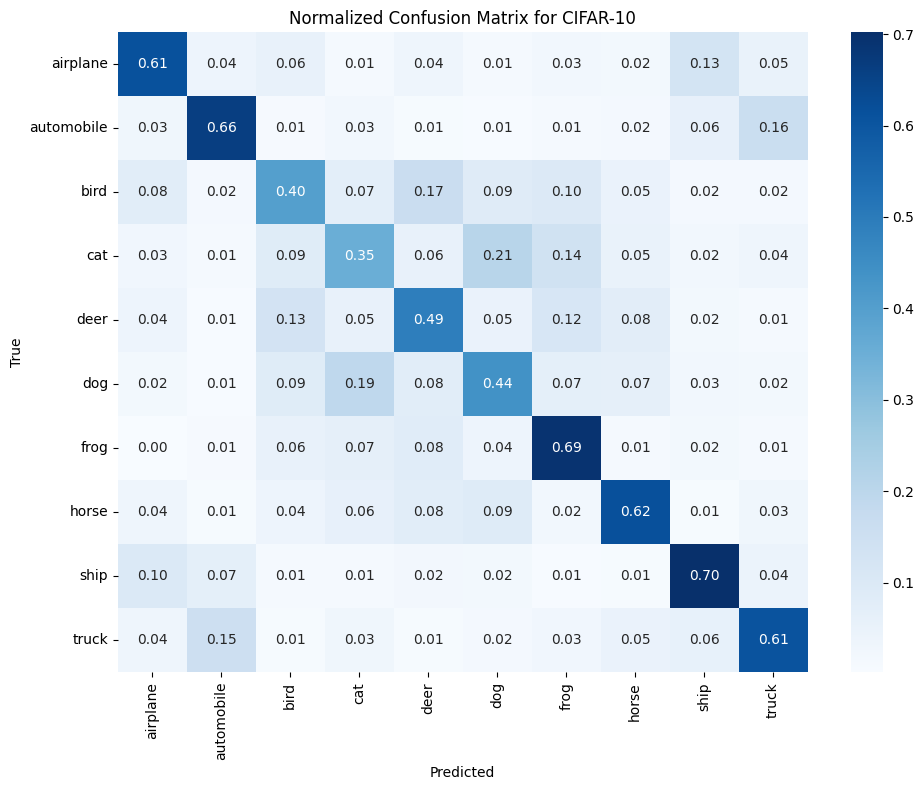

In [32]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix for CIFAR-10")
plt.tight_layout()
plt.show()

In [33]:
cm_off_diag = cm_normalized.copy()
np.fill_diagonal(cm_off_diag, 0)
print("(a) Most confused class for each true class:")
for i in range(10):
    row = cm_off_diag[i]
    j = np.argmax(row)
    print(" ", classes[i], "->", classes[j], round(row[j], 2))

(a) Most confused class for each true class:
  airplane -> ship 0.13
  automobile -> truck 0.16
  bird -> deer 0.16
  cat -> dog 0.21
  deer -> bird 0.13
  dog -> cat 0.19
  frog -> deer 0.08
  horse -> dog 0.09
  ship -> airplane 0.1
  truck -> automobile 0.16


In [34]:
max_idx = np.unravel_index(np.argmax(cm_off_diag), cm_off_diag.shape)
print("(b) Most confused pair:", classes[max_idx[0]], "and", classes[max_idx[1]], round(cm_off_diag[max_idx], 2))

(b) Most confused pair: cat and dog 0.21
